In [138]:
from pathlib import Path
import os
import subprocess
import getpass

def local_run():
    if os.path.exists("/content"):
        # running in Google Colab
        return False
    else:
        # running locally
        return True

def get_base_dir():
    if local_run():
        # running locally
        return Path(__vsc_ipynb_file__).resolve().parent.parent
    else:
        # running in Google Colab
        return Path("/content/deforestation-unet")

base_dir = get_base_dir()

In [2]:

token = getpass.getpass("Enter your GitHub token: ")
repo_url = f"https://{token}@github.com/barbara-barta/deforestation-unet.git"
if not base_dir.exists():
    print("Repository does not exist, cloning it now.")
    subprocess.run(["git", "clone", repo_url], check=True)
else:
    print("Repository already exists, pulling the latest changes.")
    subprocess.run(["git", "-C", str(base_dir), "pull"], check=True)

Repository already exists, pulling the latest changes.


In [14]:
%pip install -r {base_dir}/requirements.txt

   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---------------------------------------- 4.3/4.3 MB 34.1 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [173]:
import torch
import rasterio as rio
import rasterio.plot as rplt
import geopandas as gpd
import numpy as np
import random
import matplotlib.pyplot as plt
import torchvision
import patoolib

In [174]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}.")

# Function for setting the seed
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        
set_seed(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Using device: cpu.


In [5]:


paths = {
    "RGB": base_dir / "data" / "RGB" /"raw",
    "AM4": base_dir / "data" / "AM4" / "raw",
    "AT4": base_dir / "data" / "AT4" / "raw",
}

downloads = {
    "RGB": ["https://doi.org/10.5281/zenodo.3233081", "Amazon Forest Dataset.rar"],
    "AM4": ["https://doi.org/10.5281/zenodo.4498086","AMAZON.rar"] }
    #"AT4": ["https://doi.org/10.5281/zenodo.4498086","ATLANTIC FOREST.rar"]}

for path in paths.values():
    path.mkdir(parents=True, exist_ok=True)

for dataset, [url, filename] in downloads.items():

    zipped_data_present = list(Path(paths[dataset]).glob("*.rar"))
    if not zipped_data_present:
        print(f"Downloading {dataset} data...")
        cmd = ["zenodo_get", "-o", str(paths[dataset]), "-g", filename] + [url]
        subprocess.run(cmd, check=True)
        print(f"Dataset {dataset} downloaded to {str(paths[dataset])}.")
    else:
        print(f"Zipped {dataset} data already exists at {str(paths[dataset])}, skipping download.")
    
    unziped_data_present = any(p.is_dir() for p in paths[dataset].iterdir())
    if not unziped_data_present:
        print(f"Unzipping {dataset} data...")
        patoolib.extract_archive(str(paths[dataset] / filename), outdir=str(paths[dataset]))
        
    src = paths[dataset] / filename.rsplit(".")[0]
    new_filename = filename.lower().replace(" ", "_").rsplit(".")[0]
    dst = paths[dataset] / new_filename
    
    if src.exists():
        src.rename(dst)
    print(f"Unzipped  {dataset} dataset is located in {str(paths[dataset])}.")
    


Zipped RGB data already exists at C:\Users\barba\Documents\ProfessionalBetterment\deforestation-unet\data\RGB\raw, skipping download.
Unzipped  RGB dataset is located in C:\Users\barba\Documents\ProfessionalBetterment\deforestation-unet\data\RGB\raw.
Zipped AM4 data already exists at C:\Users\barba\Documents\ProfessionalBetterment\deforestation-unet\data\AM4\raw, skipping download.
Unzipped  AM4 dataset is located in C:\Users\barba\Documents\ProfessionalBetterment\deforestation-unet\data\AM4\raw.


If you see a WIN5 access denied error, restart the kernel and rerun the code. 

# Data exploration

In [17]:
img = "Amazon_122.tiff_33.tiff"
img_path = base_dir / "data" / "DummyData" / img
src = rio.open(img_path)
src.meta

{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': None,
 'width': 512,
 'height': 512,
 'count': 3,
 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'),
 'transform': Affine(9.016735026040612e-05, 0.0, -47.414771816388885,
        0.0, -8.990264377170196e-05, -4.399063756666667)}

In [18]:
#expressed in degrees as crs = WGS 84
print(f"Spatial resolution is {src.res} degrees.") 
print(f"Bounds of the area are {src.bounds} degrees.")

Spatial resolution is (9.016735026040612e-05, 8.990264377170196e-05) degrees.
Bounds of the area are BoundingBox(left=-47.414771816388885, bottom=-4.4450939102777784, right=-47.36860613305556, top=-4.399063756666667) degrees.


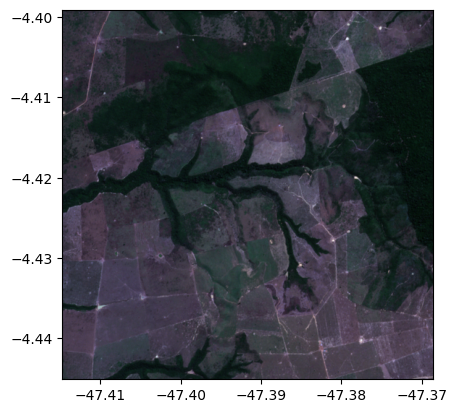

<Axes: >

In [19]:
rplt.show(src)

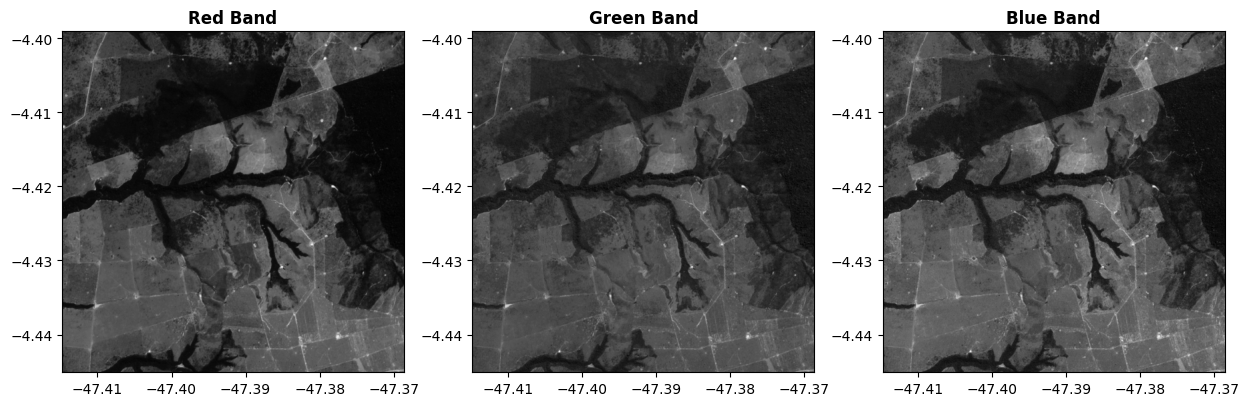

In [20]:
nr_bands = src.count
fig, axes = plt.subplots(1, nr_bands, figsize=(15, 15))
axes = axes.flatten()
titles = ["Red Band", "Green Band", "Blue Band"]
for i in range(axes.shape[0]):
    rplt.show((src, i+1), ax=axes[i], cmap='Greys_r', title = titles[i])

In [49]:
img = "S2A_MSIL2A_20200111T142701_N0213_R053_T20NQG_20200111T164651_01_07.tif" 
img_path = base_dir / "data" / "AM4" / "raw" / "amazon" / "Training" / "image" / img
src = rio.open(img_path)
src.meta

{'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': None,
 'width': 512,
 'height': 512,
 'count': 4,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 20N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-63],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32620"]]'),
 'transform': Affine(10.0, 0.0, 730680.0,
        0.0, -10.0, 200040.0)}

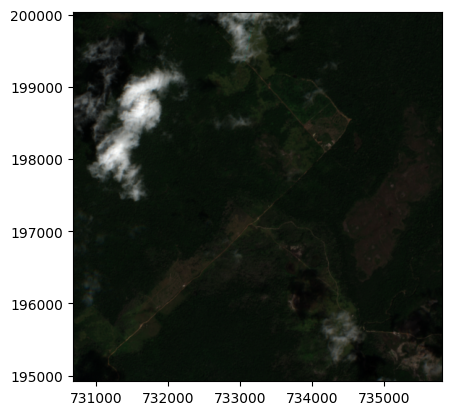

<Axes: >

In [22]:

rplt.show(src)

In [51]:
# NIR band
src.read(4)
src.profile

{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': None, 'width': 512, 'height': 512, 'count': 4, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 20N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-63],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32620"]]'), 'transform': Affine(10.0, 0.0, 730680.0,
       0.0, -10.0, 200040.0), 'blockxsize': 256, 'blockysize': 256, 'tiled': True, 'compress': 'lzw', 'interleave': 'pixel'}

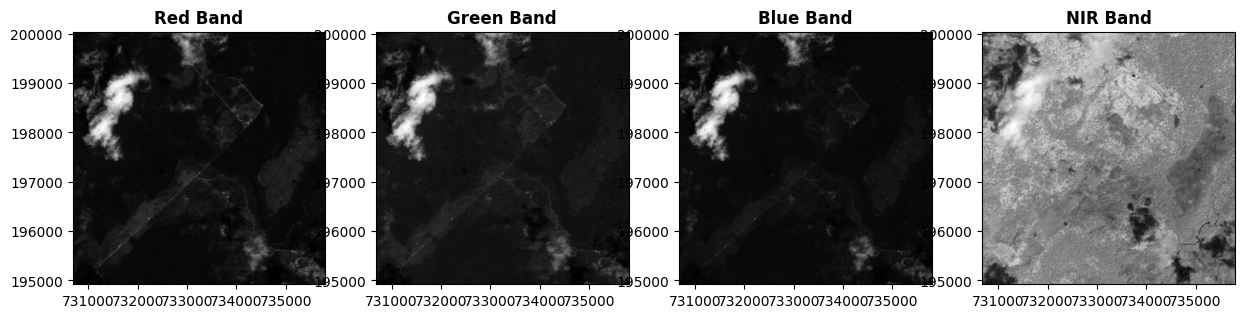

In [24]:
nr_bands = src.count
fig, axes = plt.subplots(1, nr_bands, figsize=(15, 15))
axes = axes.flatten()
titles = ["Red Band", "Green Band", "Blue Band", "NIR Band"]
for i in range(axes.shape[0]):
    rplt.show((src, i+1), ax=axes[i], cmap='Greys_r', title = titles[i])

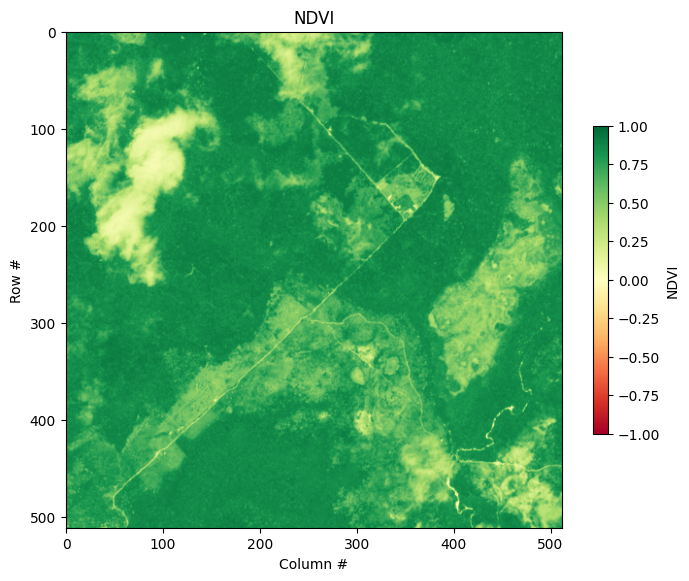

In [25]:
nir_band = src.read(4).astype('float32')
red_band = src.read(1).astype('float32')
ndvi = (nir_band - red_band) / (nir_band + red_band)
ndvi = ndvi.clip(-1, 1)

plt.figure(figsize=(8, 8))
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI", shrink=0.5)
plt.title("NDVI")
plt.xlabel("Column #")
plt.ylabel("Row #")
plt.show()

## Dataset quality concerns

RGB:
- 60 imgs from sentinel-2 satelite imagery
- max 30% cloud coverage in each picture
- 8-BIT geoTiff format?
- sr: 10m/pixel
- forest masks obtained from a land use classification process using GRASS-GIS 7.6.1 software -> automated 
AM4:


# Creating the dataset class and data loader

In [161]:
from torch.utils.data import Dataset, DataLoader
class DeforestationDataset(Dataset):
    def __init__(self, root_directory,image_name,label_name,indices = None, transform=None):
        self.root_directory = root_directory
        self.image_directory = self.root_directory / str(image_name)
        self.label_directory = self.root_directory / str(label_name)
        self.transform = transform
        self.indices = indices
        
    def __len__(self):
        if self.indices:
            dataset_size = len(self.indices)
        else:
            dataset_size = len(list(Path(self.root_directory).glob("*")))
        return dataset_size
    
    def __getitem__(self, index):
        if self.indices:
            img_path = list(Path(self.image_directory).glob("*"))[self.indices[index]]
        else:
            img_path = list(Path(self.image_directory).glob("*"))[index]
        img = rio.open(img_path)
        img = img.read().astype('float32')
        if self.transform:
            img = self.transform(img)
            
        lbl_path = list(Path(self.label_directory).glob("*"))[index]
        lbl = rio.open(lbl_path)
        lbl = lbl.read().astype('int8')
        
        sample = [img,lbl]
        return sample

train_dataset = DeforestationDataset(base_dir / "data" / "AM4" / "raw" / "amazon" / "Training","image","label",indices=list(range(250)))
sample = train_dataset[1]
data_loader = DataLoader(train_dataset,batch_size=1, shuffle=True)
#next(iter(data_loader))
#sample[0]


In [167]:
from torchvision import transforms

class min_max_scale():
    def __init__(self):
        pass
    def __call__(self,img):
        img_min,img_max = np.min(img),np.max(img)
        img_scaled =  (img - img_min)/(img_max-img_min) 
        return img_scaled  
    
class to_tensor():
    def __init__(self):
        pass
    def __call__(self,img):
        return torch.from_numpy(img)
    
# class transpose():
#     def __init__(self):
#         pass
#     def __call__(self,img):
#         return img.T
    
# class reshape():
#     def __init__(self,shape):
#         self.shape = shape
#     def __call__(self,img):
#         return np.reshape(img,self.shape)

train_transform = transforms.Compose([
    min_max_scale(),
    #reshape((4,512,512)),
    to_tensor()
])

train_dataset = DeforestationDataset(base_dir / "data" / "AM4" / "raw" / "amazon" / "Training","image","label",transform = train_transform)

sample = train_dataset[0][0] #first sample, image only
print(f"After transform, min of sample is {torch.min(sample)}, max is {torch.max(sample)}.") # check
print(f"After transform, shape of sample is {sample.shape}") # check

type(train_dataset)


After transform, min of sample is 0.0, max is 1.0.
After transform, shape of sample is torch.Size([4, 512, 512])


__main__.DeforestationDataset

In [171]:
data_loader_batched = DataLoader(train_dataset,batch_size=2, shuffle=True,num_workers=0)
next(iter(data_loader_batched))[0].shape

torch.Size([2, 4, 512, 512])

# U-net architecture

In [248]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self,n_input,n_output):
        super().__init__()
        self.linear1 = nn.Conv2d(n_input,n_output,kernel_size=3, stride =1, padding=1)
        self.relu1 = nn.ReLU(inplace=True)
        self.linear2 = nn.Conv2d(n_output,n_output,kernel_size=3, stride =1, padding=1)
        self.relu2 = nn.ReLU(inplace=True)
        self.functions = nn.Sequential(self.linear1,self.relu1,self.linear2,self.relu2)
    
    def forward(self,x):
         x = self.functions(x)
         return x

dconv = DoubleConv(4,16)
print(sample.shape)
print(dconv(sample).shape)

torch.Size([4, 512, 512])
torch.Size([16, 512, 512])


In [256]:
class Downsample(nn.Module):
    def __init__(self,n_input,n_output):
        super().__init__()
        self.functions = nn.Sequential(
            DoubleConv(n_input,n_output),nn.MaxPool2d(kernel_size=2)
        )
        
    def forward(self,x):
        return self.functions(x)
    
downsample = Downsample(4,16)
print(sample.shape)
print(downsample(sample).shape)

torch.Size([4, 512, 512])
torch.Size([16, 256, 256])


In [ ]:


class UNet(nn.Module):
    def __init__(self, num_inputs, num_outputs):
        """
        input:
        
        output: 
        
        """
        super.__init__()
        self.linear1 = nn.Linear(num_inputs,num_outputs)
        self.tanh1 = nn.Tanh()
    def forward(self,x):
        x = self.linear1(x)
        x - self.tanh1(x)
        return(x)

In [209]:
unet = uNet(2,3)
#print(unet)
x = np.zeros((2,1))
x = torch.rand(3,2)

unet.forward(x)

tensor([[-0.4590, -0.6038, -0.0126],
        [-0.5939, -0.5363,  0.0790],
        [-0.6015, -0.5660,  0.0338]], grad_fn=<TanhBackward0>)

# TO DO: 
- add pytorch lightning?

### Done this session
- continue implementation of u-net
- implement layer of 2D convol 3x3 + Relu + bridge conn + max pooling 2x2 as a block ? 
## Next time
